In [64]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import calendar

# Domain & Period

In [65]:
iyear=1940
fyear=2025
dom='HMA'
latS,latN,lonW,lonE = coord_domain(dom)

# Elevation data

In [66]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_era5_grid.nc')['elevation']

# Seasonal Mean data

In [67]:
tp = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/era5/tp.mon_era5_1940-2025_NH_025x025.nc')['tp']
tp = tp.rename({'valid_time': 'time'})
tp = field_dom(tp, dom)
tp = tp.sel(time=slice(str(iyear),str(fyear)))

# Convert m/day to mm/month
days_in_month = tp['time'].dt.days_in_month
tp = tp * days_in_month * 1000

In [68]:
seasons = ["DJFM","AM","JJAS","ON"]

tp_dict = {}

for season in seasons:
    tp_season = clim(tp, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
    tp_dict[season] = tp_season

550


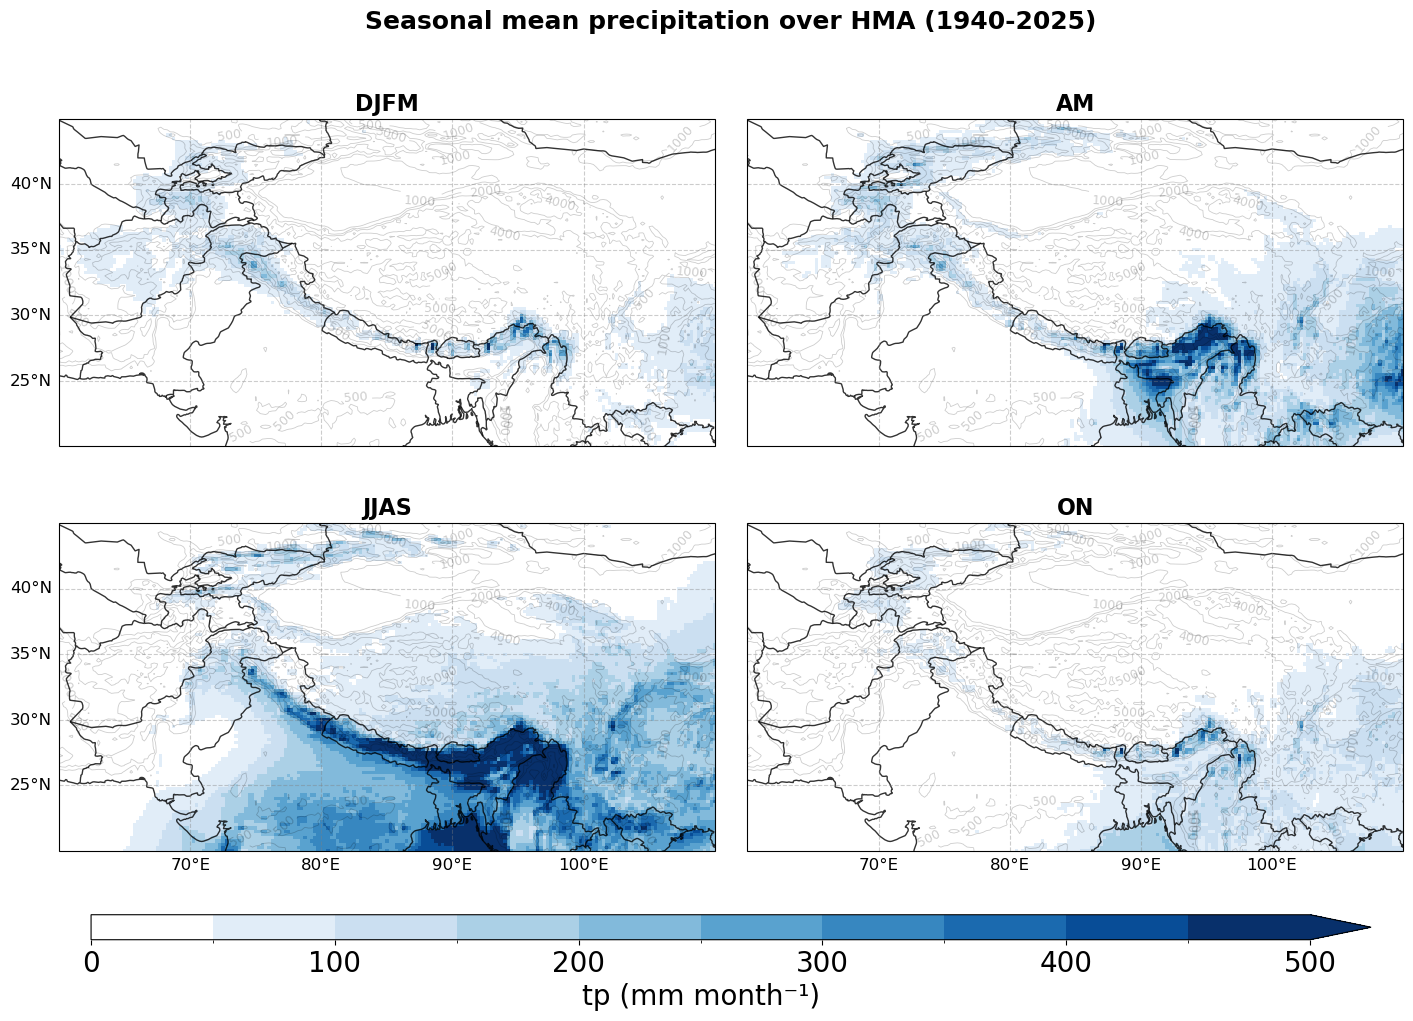

In [69]:
#==================== Color grading ============================

step = 50
vmax = 550
print(vmax)
levels = np.arange(0, vmax, step)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = tp_dict[season]
       
    im = ax.pcolormesh(
           data_model['longitude'], data_model['latitude'], data_model,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )
        
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.96, bottom=0.05, wspace=0.05, hspace=-0.2)
plt.suptitle(
    f"Seasonal mean precipitation over HMA ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()

# Seasonal Trends data

In [72]:
seasons = {"DJFM": [12,1,2,3], 
           "AM": [4,5], 
           "JJAS": [6,7,8,9], 
           "ON": [10,11]}

trend_dict = {}
p_dict={}

for season in seasons:
    tp_season = seasonal_selection2(tp, seasons[season], iyear, fyear)
    par = trend_vect(tp_season.time, tp_season, dim='time')
    trend=par[0]; p=par[3]
    trend_dict[season]=trend
    p_dict[season]=p

2.5


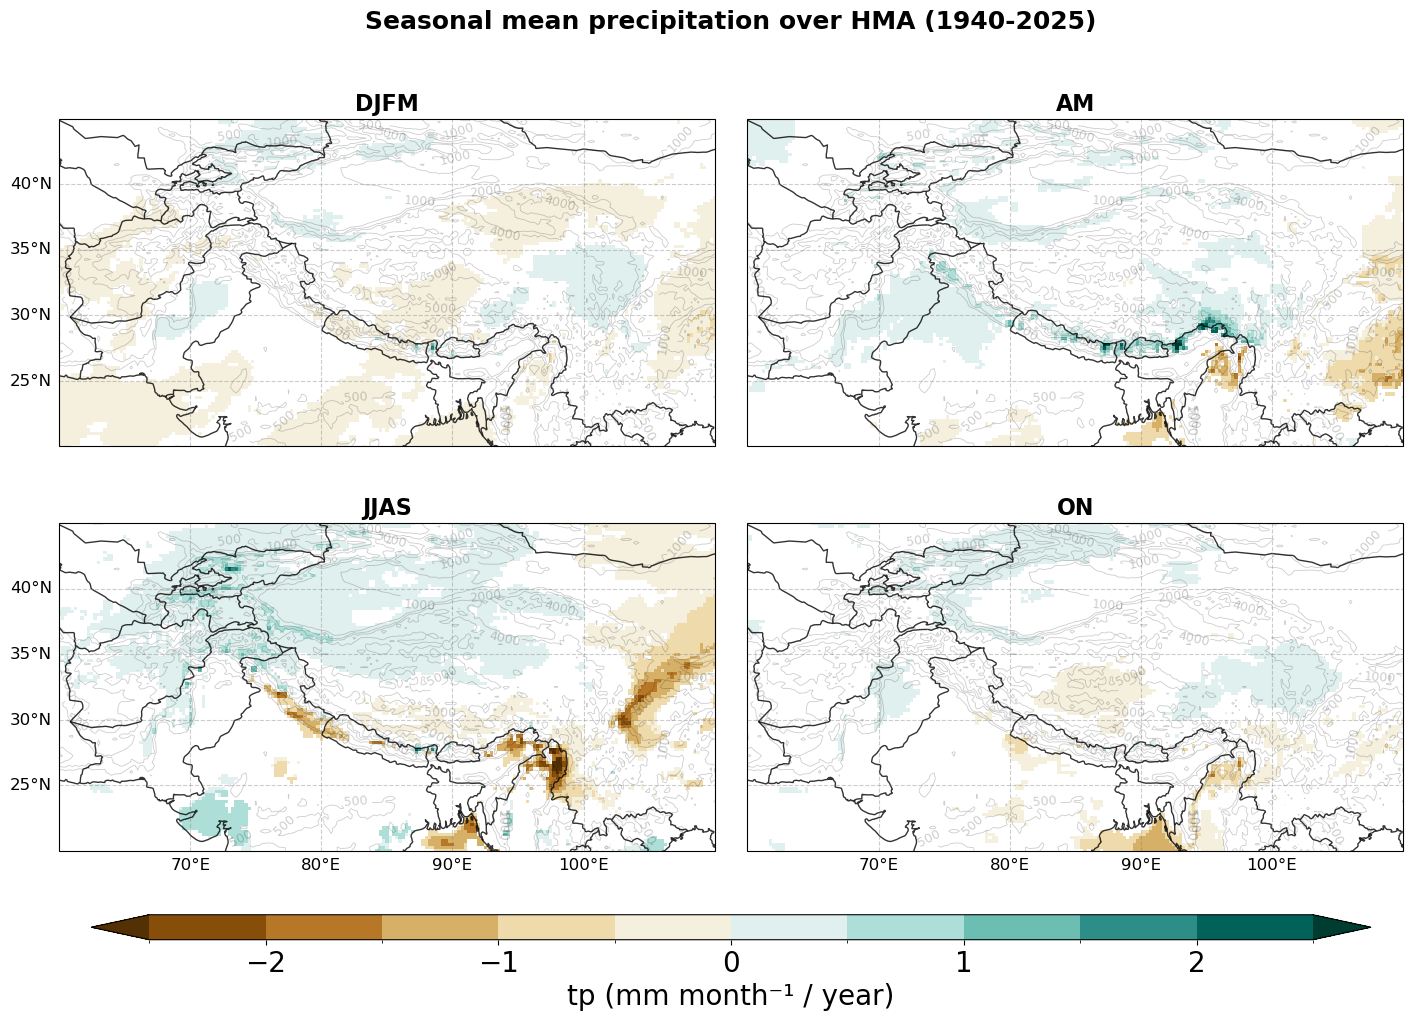

In [77]:
seasons = ['DJFM','AM','JJAS','ON']

#==================== Color grading ============================

step = 0.5
vmax = 2.5
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
cmap = cmap.copy()         # permet de modifier
cmap.set_bad(color='white')  # les NaN apparaissent en blanc
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = trend_dict[season]

    # Masque blanc pour zones non significatives
    sig = p_dict[season] < 0.05  # True = significatif
    
    # Crée une copie pour le plot avec NaN pour non significatif
    data_plot = data_model.where(sig)
    
    im = ax.pcolormesh(
           data_model['longitude'], data_model['latitude'], data_plot,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )
    
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp (mm month⁻¹ / year)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.96, bottom=0.05, wspace=0.05, hspace=-0.2)
plt.suptitle(
    f"Seasonal mean precipitation over HMA ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()